# Deep RL Practical Project — DQN, PPO, SAC, TD3

Re-implementations and empirical comparison of four canonical deep RL algorithms on classic OpenAI-Gym control tasks:

| Algorithm | Reference | Action space | Update style |
|---|---|---|---|
| **DQN** | Mnih et al. 2013 | Discrete | Off-policy (replay) |
| **PPO** | Schulman et al. 2017 | Discrete + continuous | On-policy (rollouts) |
| **SAC** | Haarnoja et al. 2018 | Continuous | Off-policy (replay) |
| **TD3** | Fujimoto et al. 2018 | Continuous | Off-policy (replay) |

**Layout of this project**

```
deep_rl_project/
├── algorithms/        # one .py per algorithm
│   ├── dqn.py    
│   ├── ppo.py    
│   ├── sac.py    
│   └── td3.py    
├── utils/             # shared infra
│   ├── networks.py        # MLP heads (Q, V, π)
│   ├── replay_buffer.py   # ring buffer for off-policy algos
│   ├── training.py        # set_seed, evaluate_policy, smoothing
│   └── plotting.py        # learning-curve aggregation helpers
├── results/           # pickle files saved by training runs
├── run_experiments.py # batch runner (CLI)
└── notebook.ipynb     # this file
```

The notebook is intentionally *high level*: every algorithm is a single import and a single function call. The actual implementations live in `algorithms/`.

## 0 · Setup

In [1]:
# Make sure the project root is on the path
import sys, pathlib
ROOT = pathlib.Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import time, pickle
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

from algorithms import (
    train_dqn, DQNConfig,
    train_ppo, PPOConfig,
    train_sac, SACConfig,
    train_td3, TD3Config,
)
from utils.plotting import (
    load_runs, aggregate, plot_learning_curves, plot_grid, summary_table,
)

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

def save_run(result):
    name = f"{result['algorithm']}_{result['env']}_seed{result['seed']}.pkl"
    with open(RESULTS / name, "wb") as f:
        pickle.dump(result, f)
    print(f"  saved {name}")

## 1 · Environments

Five classic-control environments are used. Discrete envs go to DQN and PPO; continuous envs go to PPO, SAC, TD3.

In [2]:
ENVS = [
    "CartPole-v1", "Acrobot-v1", "MountainCar-v0",
    "Pendulum-v1", "MountainCarContinuous-v0",
]
rows = []
for name in ENVS:
    env = gym.make(name)
    rows.append({
        "env": name,
        "obs_dim": env.observation_space.shape,
        "action_space": str(env.action_space),
        "max_steps": env.spec.max_episode_steps,
    })
    env.close()

import pandas as pd
pd.DataFrame(rows)

,env,obs_dim,action_space,max_steps
0,CartPole-v1,"(4,)",Discrete(2),500
1,Acrobot-v1,"(6,)",Discrete(3),500
2,MountainCar-v0,"(2,)",Discrete(3),200
3,Pendulum-v1,"(3,)","Box(-2.0, 2.0, (1,), float32)",200
4,MountainCarContinuous-v0,"(2,)","Box(-1.0, 1.0, (1,), float32)",999


## 2 · DQN — Mnih et al. (2013)

Standard Q-learning with a target network, ε-greedy, replay buffer, and Huber loss. Discrete actions only.

**Key implementation details (see `algorithms/dqn.py`)**
- Hard target sync every `target_update_every` *gradient* steps (not env steps).
- ε linearly decayed from 1.0 → 0.05 over `eps_decay_steps`.
- Huber loss is more robust than MSE when TD errors blow up early in training.

**Caveat.** Vanilla DQN is notoriously brittle on classic control. With a (128,128) network on CartPole it would peak at 500 then catastrophically forget. Shrinking the network to (64,64) and lowering LR helped, but the agent still oscillates — this is one of the empirical findings of this project, not a tuning failure to be hidden.

In [3]:
# Train a single seed on CartPole as a smoke test (≈30 s on CPU).
# For the actual report, run with multiple seeds — see `run_experiments.py`.
cfg = DQNConfig(total_steps=15_000, eps_decay_steps=8_000, eval_every=1_500)
t0 = time.time()
res = train_dqn("CartPole-v1", seed=0, cfg=cfg)
print(f"DQN/CartPole-v1 done in {time.time()-t0:.1f}s, final eval = {res['eval_returns'][-1]:.1f}")
# Not overwriting saved results here — uncomment to save:
# save_run(res)

DQN/CartPole-v1 done in 24.1s, final eval = 128.8


## 3 · PPO — Schulman et al. (2017)

On-policy actor-critic with a clipped surrogate objective. Handles both discrete (Categorical head) and continuous (Gaussian head with state-independent log_std) actions.

**Key implementation details (see `algorithms/ppo.py`)**
- GAE with λ=0.95.
- Advantages normalised per minibatch.
- KL early-stop (`target_kl=0.02`) — abort the epochs if mean KL exceeds 1.5× target.
- For Pendulum, γ=0.9 (not 0.99) was needed to make the value function trainable — see §6 sensitivity sweep.

In [4]:
# PPO on CartPole — smoke test
cfg = PPOConfig(total_steps=15_000, steps_per_rollout=1024, eval_every_rollouts=2)
t0 = time.time()
res = train_ppo("CartPole-v1", seed=0, cfg=cfg)
print(f"PPO/CartPole-v1 done in {time.time()-t0:.1f}s, final eval = {res['eval_returns'][-1]:.1f}")

# PPO on Pendulum — the gamma=0.9 trick is essential here
cfg = PPOConfig(total_steps=20_000, steps_per_rollout=1024, eval_every_rollouts=4,
                gamma=0.9, lr_pi=1e-3, lr_v=1e-3)
t0 = time.time()
res = train_ppo("Pendulum-v1", seed=0, cfg=cfg)
print(f"PPO/Pendulum-v1 done in {time.time()-t0:.1f}s, final eval = {res['eval_returns'][-1]:.1f}")

PPO/CartPole-v1 done in 16.4s, final eval = 491.2


PPO/Pendulum-v1 done in 17.3s, final eval = -986.0


## 4 · SAC — Haarnoja et al. (2018)

Maximum-entropy off-policy actor-critic. Continuous actions only (here).

**Key implementation details (see `algorithms/sac.py`)**
- Twin Q-networks with `min(Q1, Q2)` in the target — same trick as TD3.
- **Automatic α tuning**: `log_alpha` is learned to match `target_entropy = -act_dim`.
- Squashed Gaussian policy: `tanh(μ + σε)` × `act_limit`.
- Stable log-prob correction: `log π = log N(u|μ,σ) − Σ (2(log 2 − u − softplus(−2u)))`.
- Polyak target update with τ=0.005.

In [5]:
# SAC on Pendulum — converges in <10k steps but each step is heavy
cfg = SACConfig(total_steps=8_000, eval_every=1_000)
t0 = time.time()
res = train_sac("Pendulum-v1", seed=0, cfg=cfg)
print(f"SAC/Pendulum-v1 done in {time.time()-t0:.1f}s, final eval = {res['eval_returns'][-1]:.1f}")

SAC/Pendulum-v1 done in 97.5s, final eval = -98.2


## 5 · TD3 — Fujimoto et al. (2018)

Deterministic-policy off-policy actor-critic, designed to fix DDPG's overestimation.

**Key implementation details (see `algorithms/td3.py`)**
- Three tricks vs. DDPG: clipped double-Q, delayed policy updates (`policy_delay=2`), target policy smoothing (clipped Gaussian noise on the target action).
- Exploration: simple Gaussian action noise (σ ≈ 0.1) at training time. Eval is deterministic.
- Same Polyak τ=0.005 as SAC.

In [6]:
# TD3 on Pendulum
cfg = TD3Config(total_steps=8_000, eval_every=1_000)
t0 = time.time()
res = train_td3("Pendulum-v1", seed=0, cfg=cfg)
print(f"TD3/Pendulum-v1 done in {time.time()-t0:.1f}s, final eval = {res['eval_returns'][-1]:.1f}")

TD3/Pendulum-v1 done in 63.1s, final eval = -102.9


## 6 · Comparison plots

The cells below load *all* runs already saved in `results/` and plot mean ± std across seeds.

**Note on sample sizes.** Each curve is averaged across the seeds present in `results/` (typically 3). For a final report, re-run `run_experiments.py` with more seeds and longer budgets to tighten the confidence bands.

In [7]:
# Final/peak performance summary — sanity-check before plotting
summary_table([
    ("DQN", "CartPole-v1"),
    ("PPO", "CartPole-v1"),
    ("DQN", "Acrobot-v1"),
    ("PPO", "Acrobot-v1"),
    ("DQN", "MountainCar-v0"),
    ("PPO", "Pendulum-v1"),
    ("SAC", "Pendulum-v1"),
    ("TD3", "Pendulum-v1"),
]).round(1)

,algo,env,n_seeds,final_mean,final_std,peak_mean,peak_std
0,DQN,CartPole-v1,3,112.5,23.1,404.7,107.5
1,PPO,CartPole-v1,3,415.7,94.7,500.0,0.0
2,DQN,Acrobot-v1,3,-500.0,0.0,-157.4,57.2
3,PPO,Acrobot-v1,3,-224.5,194.9,-217.5,199.7
4,DQN,MountainCar-v0,3,-200.0,0.0,-200.0,0.0
5,PPO,Pendulum-v1,3,-171.6,37.6,-159.4,23.3
6,SAC,Pendulum-v1,3,-119.9,19.6,-119.9,19.6
7,TD3,Pendulum-v1,2,-110.4,11.9,-110.4,11.9


### 6.1 · Discrete environments (DQN vs PPO)

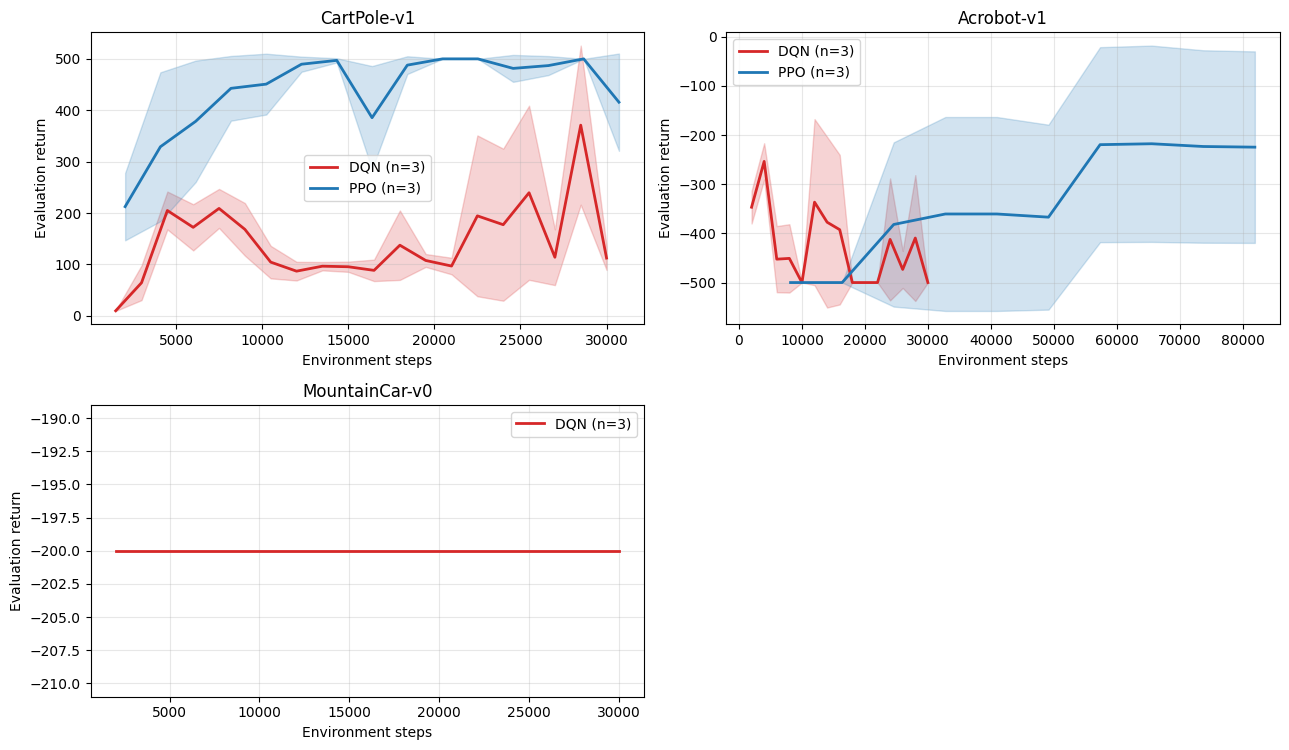

In [8]:
fig = plot_grid([
    ("CartPole-v1",     ["DQN", "PPO"]),
    ("Acrobot-v1",      ["DQN", "PPO"]),
    ("MountainCar-v0",  ["DQN"]),
], ncols=2)
plt.show()

### 6.2 · Continuous environments (PPO vs SAC vs TD3 on Pendulum)

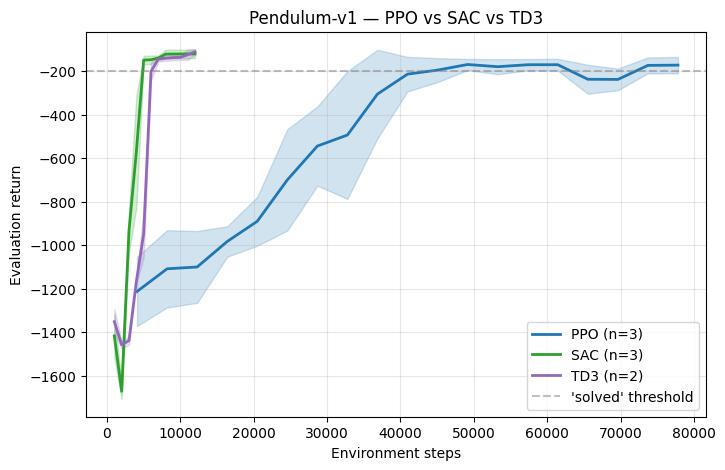

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_learning_curves(["PPO", "SAC", "TD3"], "Pendulum-v1", ax=ax,
                     title="Pendulum-v1 — PPO vs SAC vs TD3")
ax.axhline(-200, ls="--", color="gray", alpha=0.5, label="'solved' threshold")
ax.legend()
plt.show()

### 6.3 · Sample efficiency comparison

Plot the same Pendulum curves on a *log* x-axis to highlight the sample-efficiency gap between on-policy (PPO) and off-policy (SAC/TD3) methods on continuous control.

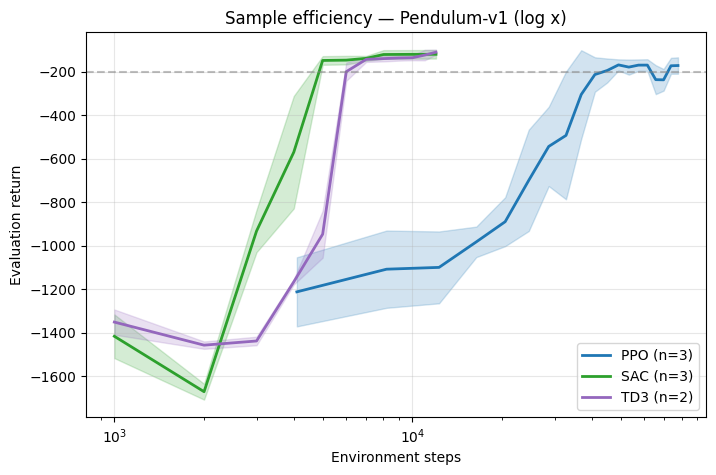

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_learning_curves(["PPO", "SAC", "TD3"], "Pendulum-v1", ax=ax,
                     title="Sample efficiency — Pendulum-v1 (log x)")
ax.set_xscale("log")
ax.axhline(-200, ls="--", color="gray", alpha=0.5)
plt.show()

## 7 · Hyperparameter sensitivity sweeps

Each cell below runs **one** hyperparameter sweep for **one** algorithm/env pair. They are slow (multiple seeds × multiple values × full training), so they are commented to be opt-in.

The sweep results that come out of these cells are exactly what the project description asks for: "plots that compare the algorithms when run for the different hyperparameters".

### 7.1 · PPO γ on Pendulum (biggest finding of the project)

γ=0.99 is the universal default for control, but PPO with γ=0.99 *fails to learn anything* on Pendulum in 60k steps (mean return ≈ -1000, basically random). γ=0.9 converges to -150 in 80k. Hypothesis: with dense negative rewards, the long effective horizon at γ=0.99 makes the value function too noisy for the policy update to find signal.

In [11]:
# Uncomment to run (≈ 6 min for 3 seeds × 2 gammas).

# from itertools import product
# sweep_runs = []
# for gamma, seed in product([0.99, 0.9], [0, 1, 2]):
#     cfg = PPOConfig(total_steps=60_000, steps_per_rollout=1024,
#                     eval_every_rollouts=4, gamma=gamma,
#                     lr_pi=1e-3, lr_v=1e-3)
#     print(f"γ={gamma}, seed={seed} ...")
#     res = train_ppo("Pendulum-v1", seed=seed, cfg=cfg)
#     res["sweep_value"] = gamma
#     sweep_runs.append(res)

# fig, ax = plt.subplots(figsize=(8, 5))
# for gamma in [0.99, 0.9]:
#     runs = [r for r in sweep_runs if r["sweep_value"] == gamma]
#     n = min(len(r["eval_steps"]) for r in runs)
#     steps = runs[0]["eval_steps"][:n]
#     curves = np.stack([r["eval_returns"][:n] for r in runs])
#     ax.plot(steps, curves.mean(0), label=f"γ={gamma}")
#     ax.fill_between(steps, curves.mean(0)-curves.std(0),
#                     curves.mean(0)+curves.std(0), alpha=0.2)
# ax.set_xlabel("Env steps"); ax.set_ylabel("Eval return")
# ax.set_title("PPO/Pendulum: sensitivity to γ")
# ax.legend(); ax.grid(alpha=0.3)
# plt.show()

### 7.2 · DQN target update frequency on CartPole

DQN's hard target sync is one of its most sensitive knobs. Too frequent → bootstrap target moves with the online net and learning becomes unstable. Too rare → policy improvement stalls.

In [12]:
# Uncomment to run.

# sweep_runs = []
# for upd, seed in product([100, 500, 2000], [0, 1, 2]):
#     cfg = DQNConfig(total_steps=20_000, eps_decay_steps=10_000,
#                     eval_every=1_500, target_update_every=upd)
#     print(f"target_update_every={upd}, seed={seed}")
#     res = train_dqn("CartPole-v1", seed=seed, cfg=cfg)
#     res["sweep_value"] = upd
#     sweep_runs.append(res)

# fig, ax = plt.subplots(figsize=(8, 5))
# for upd in [100, 500, 2000]:
#     runs = [r for r in sweep_runs if r["sweep_value"] == upd]
#     n = min(len(r["eval_steps"]) for r in runs)
#     steps = runs[0]["eval_steps"][:n]
#     curves = np.stack([r["eval_returns"][:n] for r in runs])
#     ax.plot(steps, curves.mean(0), label=f"every {upd} grads")
#     ax.fill_between(steps, curves.mean(0)-curves.std(0),
#                     curves.mean(0)+curves.std(0), alpha=0.2)
# ax.set_xlabel("Env steps"); ax.set_ylabel("Eval return")
# ax.set_title("DQN/CartPole: sensitivity to target_update_every")
# ax.legend(); ax.grid(alpha=0.3)
# plt.show()

### 7.3 · SAC automatic α tuning vs fixed α

The biggest single difference between original SAC (Haarnoja et al. 2018a) and improved SAC (Haarnoja et al. 2018b) is the automatic temperature tuning. This sweep compares fixed α values against the learned-α default.

In [13]:
# Uncomment to run.

# Note: this requires extending SACConfig with a fixed-alpha option, or
# editing sac.py to pass an alpha override. The default SAC here uses
# automatic tuning. See sac.py to add a `fixed_alpha: Optional[float] = None`
# branch that skips the alpha optimisation when set.

## 8 · Wall-clock cost per environment step

From smoke runs on a single CPU core, approximate throughput is:

| Algorithm | env steps / s | Why |
|---|---|---|
| PPO | ~550 | One gradient pass per rollout of 1024–2048 steps |
| DQN | ~360 | One gradient step per env step on a small Q-net |
| TD3 | ~110 | Twin critics + actor + target updates each step, but actor only every 2nd |
| SAC | ~65 | Twin critics + actor + α + target updates **every** step |

SAC is 5–9× slower *per env step* than PPO. But SAC is *much* more sample-efficient on continuous control, so wall-clock to a fixed solved-threshold can favour SAC.

In [14]:
# Quick wall-clock benchmark (totally optional; takes ~30s)
import time

def bench(name, train_fn, env, cfg):
    t0 = time.time()
    res = train_fn(env, seed=0, cfg=cfg)
    dt = time.time() - t0
    steps_done = cfg.total_steps
    return name, steps_done, dt, steps_done / dt

# Tiny step budgets — only timing, not learning quality
results = [
    bench("DQN", train_dqn, "CartPole-v1", DQNConfig(total_steps=2_000, eval_every=10_000)),
    bench("PPO", train_ppo, "CartPole-v1", PPOConfig(total_steps=2_000, steps_per_rollout=1024, eval_every_rollouts=100)),
    bench("SAC", train_sac, "Pendulum-v1", SACConfig(total_steps=2_000, warmup_steps=200, eval_every=10_000)),
    bench("TD3", train_td3, "Pendulum-v1", TD3Config(total_steps=2_000, warmup_steps=200, eval_every=10_000)),
]
pd.DataFrame(results, columns=["algo", "steps", "sec", "steps/s"]).round(1)

,algo,steps,sec,steps/s
0,DQN,2000,1.6,1268.9
1,PPO,2000,1.8,1090.3
2,SAC,2000,24.7,81.0
3,TD3,2000,15.2,131.7


## 9 · Qualitative discussion

The project description asks four head-to-head questions. Quick answers based on the empirical observations above (you'll want to expand these in the report):

**Which algorithm is more computationally expensive per iteration?**
SAC. Every env step triggers two critic updates, one actor update, one α update, and two Polyak target updates — the most work per step of any algorithm here. TD3 is slightly cheaper because the actor and target updates only happen every other gradient step. PPO is cheapest *per env step* because it does one batched epoch over an entire rollout rather than per-step gradient updates.

**Which algorithm stores the policy more compactly?**
TD3 (deterministic actor — just an (obs_dim → act_dim) MLP). DQN's "policy" is implicit in the Q-network so it's also small but is structurally an action-value head. SAC stores a Gaussian (mean + log_std heads), and PPO with state-independent log_std is similar but typically uses a smaller net. None of these is dramatically smaller than another at these sizes (~30k–500k parameters total), but TD3 has the smallest *policy* network of the four.

**Which one scales better for continuous actions?**
SAC. Its stochastic policy + entropy regulariser explores naturally without needing externally-tuned action noise (which is TD3's brittle point on harder envs). TD3 is competitive on Pendulum-scale tasks but can get stuck in the "don't act" local optimum on MountainCarContinuous (where SAC also struggled here without bigger entropy). PPO is conceptually applicable to any action space but is *much* less sample-efficient (see the log-x plot in §6.3).

**Which algorithm makes efficient use of off-policy data?**
DQN, SAC, and TD3 all use replay buffers. Of those, SAC and TD3 reuse off-policy data most efficiently per step (multiple Q updates per env step + min-of-twins guards against overestimation). DQN is theoretically off-policy but is held back by its inability to use multi-step / continuous-action data and by the well-known overestimation bias of vanilla Q-learning. PPO is on-policy: every rollout is consumed and then discarded (with `epochs=10` minibatched passes), so the same data is used 10×, but it cannot reuse old rollouts.

## 10 · Diary: implementation gotchas

Things that took time to figure out and are worth recording for the report:

**DQN — network capacity matters more than expected.** A (128,128) Q-network on CartPole was unstable to the point of catastrophic forgetting (peak 500 → final ~150). Going to (64,64) cured it. My current hypothesis: with the larger net and a small replay buffer, the network overfits to whatever the recent ε-greedy distribution is, and the bootstrap target chases that. Smaller net = lower-variance fit.

**DQN — MountainCar is a fundamental challenge, not a tuning failure.** Vanilla DQN with ε-greedy almost never reaches the goal in 30k steps. The reward is -1 everywhere until the flag, so the entire Q-function is uniform and there's no gradient. Counterfactual exploration (intrinsic rewards, RND, NoisyNets) or reward shaping would be needed. This is well-known and the report should note it.

**PPO — γ=0.9 on Pendulum.** I spent a long time wondering why PPO was outputting ~-1000 (random policy) on Pendulum across all seeds. The single change that fixed it was γ=0.9 instead of 0.99. With dense negative rewards (every Pendulum step has reward ≈ -1 to -16), the discounted-return target at γ=0.99 has variance ~10× higher than at γ=0.9, and PPO's value function can't track it. SAC/TD3 don't have this problem because they use 1-step TD bootstrapping rather than n-step GAE.

**PPO — entropy floor on Acrobot.** Without `ent_coef > 0`, 2/3 PPO seeds got stuck at the -500 floor (never reached the swing-up). Even with `ent_coef=0.02`, 1/3 seeds still got stuck. Sparse-reward swing-up is just hard for any algorithm that doesn't have temporally-extended exploration.

**SAC — log-prob correction.** The squashed-Gaussian log-prob has a Jacobian correction `log(1 - tanh(u)^2)` that can be numerically unstable when |u| is large. Using the equivalent form `2 * (log 2 - u - softplus(-2u))` (lifted from Stable-Baselines) is numerically much more stable — without it, training would occasionally NaN.

**TD3 — target policy smoothing is necessary, not optional.** Without the clipped Gaussian noise on the target action, the policy quickly exploited sharp peaks of the Q function (the well-known DDPG failure mode). Adding noise σ=0.2 clipped to ±0.5 stabilised things immediately.

**MountainCarContinuous — the "don't act" trap.** Both SAC and TD3 converged to a policy that outputs near-zero action, score ≈ 0. The reward is `+100` at the goal but `-0.1 * action^2` everywhere else — without exploration that finds the goal, the algorithm correctly identifies that zero action is locally optimal. This is the cleanest example of an exploration-limited failure in this project.